# Hyperparameter visualization (qubit_TransmonCross_cap_matrix)
## Quantum Metal --> Capacitance

Ansys surrogate model

## Library

In [1]:
from pathlib import Path
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  ## hide gpus from tf so it doesnt try to use them and get memory errors

import json, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU, Dropout
from keras_tuner import BayesianOptimization

from parameters_surrogate import *

## Dataset

In [2]:
## load the data dimensions
def load_scaled_split(kind, split):
    return np.load(f"{DATA_DIR}/npy/{split}_{kind}_encoding_scaled.npy", allow_pickle=True)

X_test = load_scaled_split('linear', 'y_test')
y_train = load_scaled_split('linear', 'x_train')

input_dim = X_test.shape[1]
output_dim = y_train.shape[1]
print(f'Input dimension (Qiskit params): {input_dim}')
print(f'Output dimension (Capacitance):  {output_dim}')

steps_per_epoch = int(np.ceil(301 / TRAIN_BATCH_SIZE)) 
LR_DECAY_STEPS_local = steps_per_epoch * 20

Input dimension (Qiskit params): 3
Output dimension (Capacitance):  1


## Load the model and stuff

In [3]:
def build_hypermodel(hp):
    """
    same build_hypermodel in ml_01_train_keras_model2_surrogate.ipynb
    """
    tf.keras.backend.clear_session()
    gc.collect()
    
    n_layers = hp.Int('n_layers', min_value=1, max_value=5, default=3)
    neurons_per_layer = [hp.Int(f'neurons_{i}', min_value=32, max_value=512, step=32) for i in range(n_layers)]
    dropout_rate = hp.Float('dropout_rate', 0.0, 0.4, step=0.05)
    l2_reg = hp.Float('l2_reg', 1e-5, 1e-2, sampling='LOG', default=1e-4)
    lr_initial = hp.Float('learning_rate', 1e-4, 3e-3, sampling='LOG', default=5e-4)
    use_batchnorm = hp.Boolean('use_batchnorm', default=True)
    
    ## simple sequential model
    model = Sequential()
    model.add(Input(shape=(input_dim,), name='input1'))
    for i, n_units in enumerate(neurons_per_layer):
        model.add(Dense(n_units, name=f'fc{i}', kernel_initializer='he_normal',
                        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        if use_batchnorm:
            model.add(tf.keras.layers.BatchNormalization(name=f'bn{i}'))
        model.add(LeakyReLU(negative_slope=0.01, name=f'leaky_relu{i}'))
        model.add(Dropout(rate=dropout_rate, name=f'dropout{i}'))
    model.add(Dense(output_dim, name='output', kernel_initializer='he_normal'))
    model.compile(optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
                  loss=TRAIN_LOSS, metrics=[TRAIN_LOSS])
    return model

In [4]:
## load the tuner results from the training notebook's directory (wherever that is)
tuner = BayesianOptimization(
    build_hypermodel,
    objective='val_loss',
    max_trials=KERAS_TUNER_TRIALS,
    executions_per_trial=2,
    directory=KERAS_DIR + '/hyper_tuning_model2_less_layers_more_learning_rate', ## change to whatever tuner folder name we are on
    project_name='model2_mlp_tuning_bayesian',
)

tuner.reload()
print(f'Loaded {len(tuner.oracle.trials)} trials')

Reloading Tuner from /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/keras/hyper_tuning_model2_less_layers_more_learning_rate/model2_mlp_tuning_bayesian/tuner0.json
Loaded 812 trials


In [5]:
## extract the trials
all_trials = tuner.oracle.trials

results = []
for trial_id, trial in all_trials.items():
    trial_data = dict(trial.hyperparameters.values)
    
    ## extract best val_loss
    if 'val_loss' in trial.metrics.metrics:
        val_loss_history = trial.metrics.get_history('val_loss')
        trial_data['val_loss'] = min([obs.value[0] for obs in val_loss_history if obs.value])
    else:
        trial_data['val_loss'] = None

    ## calculate total neurons
    n_layers = trial_data.get('n_layers', 5)
    total_neurons = sum(trial_data.get(f'neurons_{i}', 0) for i in range(n_layers))
    trial_data['total_neurons'] = total_neurons
    trial_data['n_layers_actual'] = n_layers
    trial_data['trial_id'] = trial_id
    results.append(trial_data)

df = pd.DataFrame(results)
df = df.dropna(subset=['val_loss'])

print(f'Total completed trials: {len(df)}')
print(f'\nBest 5 trials by val_loss:')
print(df.nsmallest(5, 'val_loss')[['trial_id', 'n_layers', 'total_neurons', 'dropout_rate',
                                     'l2_reg', 'learning_rate', 'use_batchnorm', 'val_loss']].to_string(index=False))

Total completed trials: 810

Best 5 trials by val_loss:
trial_id  n_layers  total_neurons  dropout_rate   l2_reg  learning_rate  use_batchnorm  val_loss
     811         1            512           0.0 0.000022       0.039521          False  0.001803
    0192         1            320           0.0 0.000020       0.053762          False  0.001824
    0184         1            320           0.0 0.000020       0.053765          False  0.001863
    0175         1            288           0.0 0.000018       0.051406          False  0.001894
    0223         1            352           0.0 0.000019       0.053674          False  0.001911


# Look at params

val_loss dtype: float64


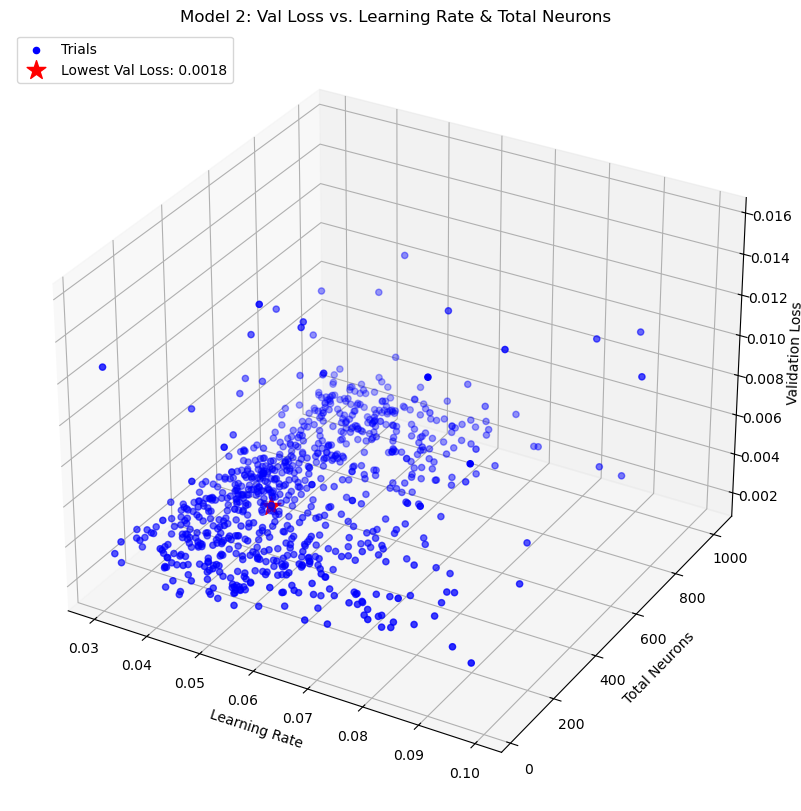

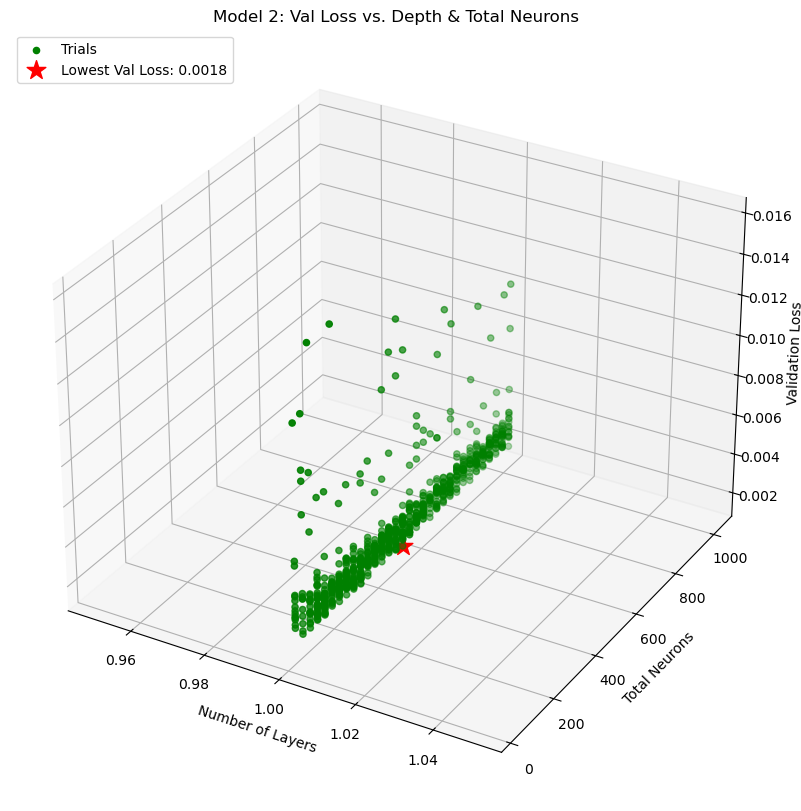

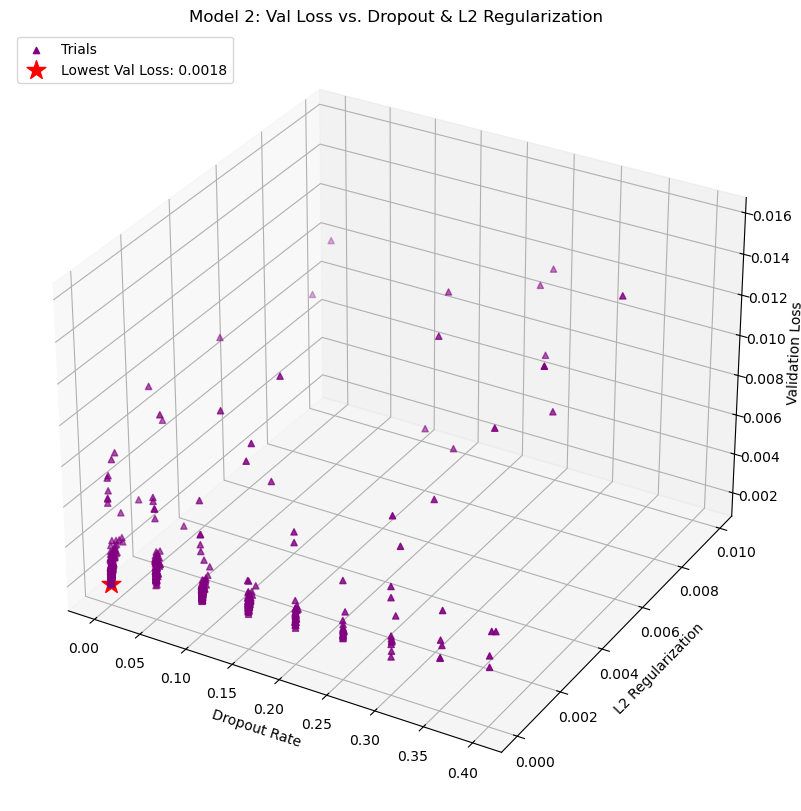

In [6]:
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(str(Path(PLOTS_DIR) / 'hypertuner_search_metrics'), exist_ok=True)

## make sure all values in 'val_loss' are numeric
print('val_loss dtype:', df['val_loss'].dtype)

filtered_df = df[df['val_loss'].notna()].copy()

min_val_loss_index = df['val_loss'].idxmin()
min_val_loss_point = df.loc[min_val_loss_index]
min_loss = round(filtered_df.loc[filtered_df['val_loss'].idxmin()]['val_loss'], 4)

## val_loss vs learning_rate vs total_neurons ###########################
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['learning_rate'], df['total_neurons'], df['val_loss'], c='blue', marker='o', label='Trials')
ax.scatter(
    min_val_loss_point['learning_rate'],
    min_val_loss_point['total_neurons'],
    min_val_loss_point['val_loss'],
    c='red', marker='*', s=200, label=f'Lowest Val Loss: {min_loss}'
)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Total Neurons')
ax.set_zlabel('Validation Loss')
ax.set_title('Model 2: Val Loss vs. Learning Rate & Total Neurons')
ax.legend(loc='upper left')
plt.savefig(str(Path(PLOTS_DIR) / 'hypertuner_search_metrics/model2_3D_Val_Loss_vs_LR_and_Neurons.png'))
plt.show()

## val_loss vs n_layers vs total_neurons ###########################
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['n_layers'], df['total_neurons'], df['val_loss'], c='green', marker='o', label='Trials')
ax.scatter(
    min_val_loss_point['n_layers'],
    min_val_loss_point['total_neurons'],
    min_val_loss_point['val_loss'],
    c='red', marker='*', s=200, label=f'Lowest Val Loss: {min_loss}'
)
ax.set_xlabel('Number of Layers')
ax.set_ylabel('Total Neurons')
ax.set_zlabel('Validation Loss')
ax.set_title('Model 2: Val Loss vs. Depth & Total Neurons')
ax.legend(loc='upper left')
plt.savefig(str(Path(PLOTS_DIR) / 'hypertuner_search_metrics/model2_3D_Val_Loss_vs_Depth_and_Neurons.png'))
plt.show()

## val_loss vs dropout_rate vs l2_reg ###########################
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['dropout_rate'], df['l2_reg'], df['val_loss'], c='purple', marker='^', label='Trials')
ax.scatter(
    min_val_loss_point['dropout_rate'],
    min_val_loss_point['l2_reg'],
    min_val_loss_point['val_loss'],
    c='red', marker='*', s=200, label=f'Lowest Val Loss: {min_loss}'
)
ax.set_xlabel('Dropout Rate')
ax.set_ylabel('L2 Regularization')
ax.set_zlabel('Validation Loss')
ax.set_title('Model 2: Val Loss vs. Dropout & L2 Regularization')
ax.legend(loc='upper left')
plt.savefig(str(Path(PLOTS_DIR) / 'hypertuner_search_metrics/model2_3D_Val_Loss_vs_Dropout_and_L2.png'))
plt.show()

/tmp/ipykernel_237079/355492791.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


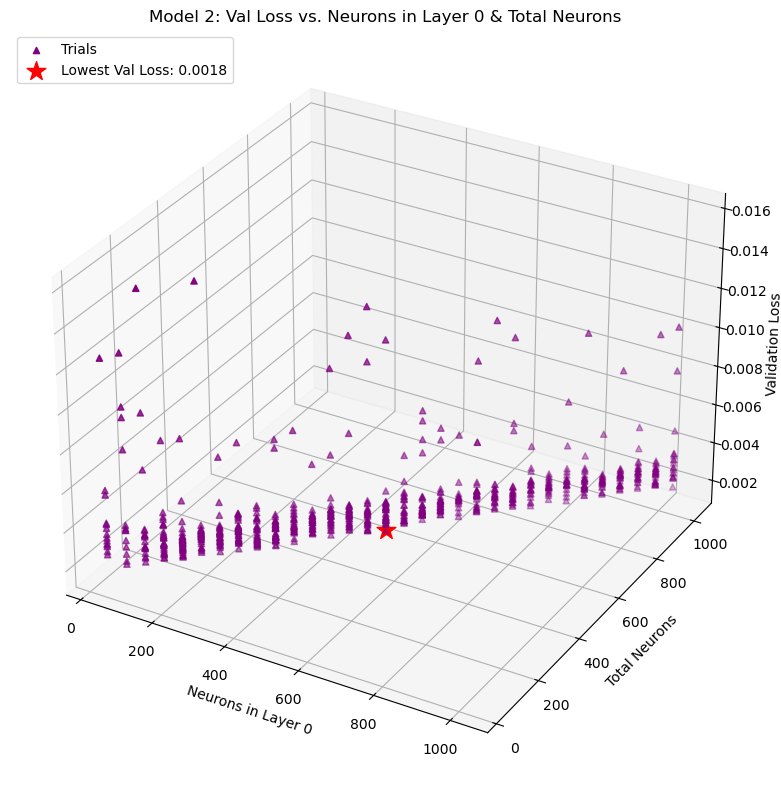

In [7]:
## perlayer neuron plots ###########################
max_layers_seen = int(df['n_layers'].max()) if 'n_layers' in df.columns else 5
for i in range(max_layers_seen):
    col = f'neurons_{i}'
    if col not in df.columns:
        continue
    layer_df = df[df[col].notna()].copy()
    if len(layer_df) < 2:
        continue

    fig = plt.figure(figsize=(10, 8), constrained_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(layer_df[col], layer_df['total_neurons'], layer_df['val_loss'], c='purple', marker='^', label='Trials')

    if col in min_val_loss_point and pd.notna(min_val_loss_point.get(col)):
        ax.scatter(
            min_val_loss_point[col],
            min_val_loss_point['total_neurons'],
            min_val_loss_point['val_loss'],
            c='red', marker='*', s=200, label=f'Lowest Val Loss: {min_loss}'
        )

    ax.set_xlabel(f'Neurons in Layer {i}')
    ax.set_ylabel('Total Neurons')
    ax.set_zlabel('Validation Loss')
    ax.set_title(f'Model 2: Val Loss vs. Neurons in Layer {i} & Total Neurons')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/hypertuner_search_metrics/model2_3D_Val_Loss_vs_Neurons_Layer_{i}.png')
    plt.show()

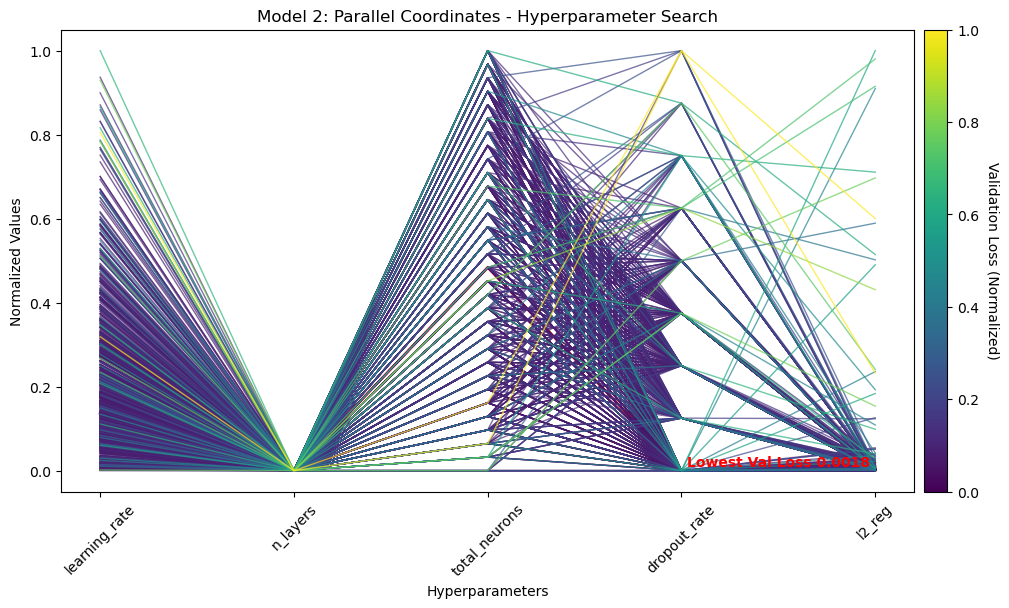

In [8]:
## columns to include in parallel coordinates
columns_to_include = ['learning_rate', 'n_layers', 'total_neurons', 'dropout_rate', 'l2_reg', 'val_loss']

filtered_df = df[columns_to_include].dropna()

## normalize the data for better visualization
norm_df = filtered_df.copy()
norm_df[columns_to_include] = filtered_df[columns_to_include].apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-12))

## normalize val_loss for color mapping
norm_df['val_loss_normalized'] = (filtered_df['val_loss'] - filtered_df['val_loss'].min()) / (filtered_df['val_loss'].max() - filtered_df['val_loss'].min() + 1e-12)

## sort by val_loss
norm_df = norm_df.sort_values(by='val_loss').reset_index(drop=True)

## generate colors
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=norm_df['val_loss_normalized'].min(), vmax=norm_df['val_loss_normalized'].max())
colors = [cmap(norm(val)) for val in norm_df['val_loss_normalized']]

min_val_loss_index = norm_df['val_loss'].idxmin()
min_loss = round(filtered_df.loc[filtered_df['val_loss'].idxmin()]['val_loss'], 4)

## plot parallel coordinates
fig, ax = plt.subplots(figsize=(14, 6))
plot_cols = columns_to_include[:-1]  ## everything except val_loss on the xaxis
for idx, row in norm_df.iterrows():
    line = ax.plot(
        plot_cols,
        row[plot_cols],
        color='red' if idx == min_val_loss_index else colors[idx],
        alpha=1.0 if idx == min_val_loss_index else 0.7,
        linewidth=2.0 if idx == min_val_loss_index else 1.0
    )
    if idx == min_val_loss_index:
        ax.text(
            len(plot_cols) - 1.5,
            row[plot_cols].iloc[-1] + 0.01,
            f'Lowest Val Loss {min_loss}',
            color='red', fontsize=10, fontweight='bold', ha='center'
        )

plt.subplots_adjust(right=0.85)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label('Validation Loss (Normalized)', rotation=270, labelpad=15)

ax.set_title('Model 2: Parallel Coordinates - Hyperparameter Search')
ax.set_xlabel('Hyperparameters')
ax.set_ylabel('Normalized Values')
ax.set_xticks(range(len(plot_cols)))
ax.set_xticklabels(plot_cols, rotation=45)
plt.savefig(str(Path(PLOTS_DIR) / 'hypertuner_search_metrics/model2_parallel_coordinates.png'))
plt.show()

In [9]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

## print everything as a dict
print('All best hyperparameters:')
print(json.dumps({k: (round(v, 6) if isinstance(v, float) else v)
                  for k, v in best_hps.values.items()}, indent=2))

n_layers_best = best_hps.values.get('n_layers', 5)

print('Key hyperparameters')
print(f'  n_layers:       {n_layers_best}')
for i in range(n_layers_best):
    print(f'  neurons_{i}:      {best_hps.values.get(f"neurons_{i}")}')
print(f'  dropout_rate:   {best_hps.get("dropout_rate")}')
print(f'  l2_reg:         {best_hps.get("l2_reg")}')
print(f'  learning_rate:  {best_hps.get("learning_rate")}')
print(f'  use_batchnorm:  {best_hps.get("use_batchnorm")}')

All best hyperparameters:
{
  "n_layers": 1,
  "neurons_0": 512,
  "dropout_rate": 0.0,
  "l2_reg": 2.2e-05,
  "learning_rate": 0.039521,
  "use_batchnorm": false
}
Key hyperparameters
  n_layers:       1
  neurons_0:      512
  dropout_rate:   0.0
  l2_reg:         2.236357497797071e-05
  learning_rate:  0.039520518973613625
  use_batchnorm:  False
